In [48]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the Meshgrid
feature_x = np.linspace(-3.5, 3.5, 400)
feature_y = np.linspace(-3.5, 3.5, 400)
X, Y = np.meshgrid(feature_x, feature_y)
R = np.sqrt(X**2 + Y**2)

# 2. Define Context (The specific problem instance)
target_angle = np.pi / 4  # 45 degrees
target_r = 3.0 # The unconstrained minimum (infeasible)

# The Objective Function
Z_obj = (X - target_r * np.cos(target_angle))**2 + (Y - target_r * np.sin(target_angle))**2

# 3. Define Constraints (The Donut: 1 <= r <= 2)
# We create a mask where 1 is Infeasible, 0 is Feasible
infeasible_mask = (R < 1) | (R > 2)

# 4. Generate "Imperfect Labels"
np.random.seed(42) # Fixed seed for reproducibility
n_labels = 10
label_r = 2.0 + np.random.normal(0, 0.25, n_labels) # Radius noise
label_theta = target_angle + np.random.normal(0, 0.4, n_labels) # Angle noise
labels_x = label_r * np.cos(label_theta)
labels_y = label_r * np.sin(label_theta)

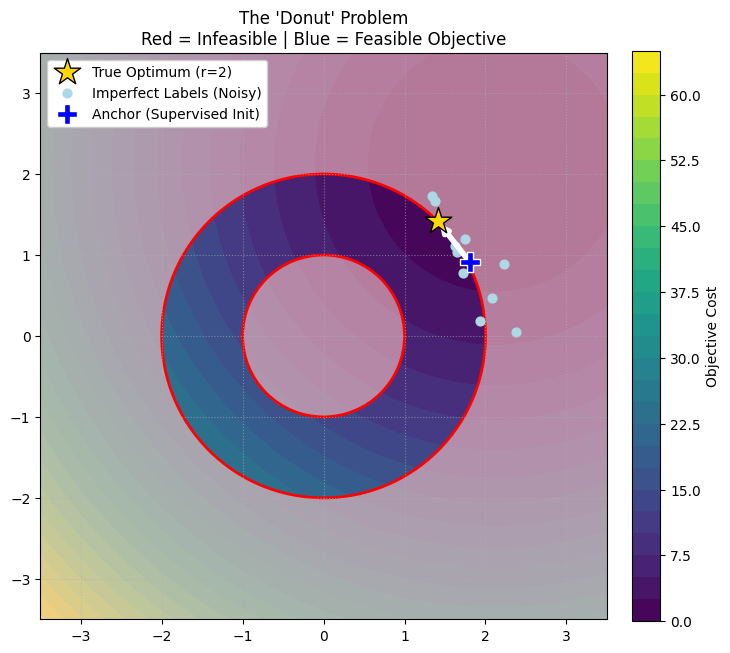

In [49]:
# 5. Plotting
fig, ax = plt.subplots(figsize=(8, 8))

# --- A. Plot the Objective Function (The "Slope") ---
# We plot this everywhere first
contour = ax.contourf(X, Y, Z_obj, levels=30, cmap='viridis', alpha=1.0)
fig.colorbar(contour, ax=ax, fraction=0.046, pad=0.04, label='Objective Cost')

# --- B. Plot the Infeasible Region (The "Walls") ---
# We overlay a solid color (Light Red) where constraints are violated
# This creates the visual effect of a "safe corridor"
ax.contourf(X, Y, infeasible_mask, levels=[0.5, 1.5], colors=["#ffc4c4"], alpha=0.6)

# Add boundaries for crispness
circle_inner = plt.Circle((0, 0), 1, color='red', fill=False, linestyle='-', linewidth=2)
circle_outer = plt.Circle((0, 0), 2, color='red', fill=False, linestyle='-', linewidth=2)
ax.add_patch(circle_inner)
ax.add_patch(circle_outer)

# --- C. Plot Data Points ---

# 1. The True Optimum (Constrained)
true_opt_x = 2.0 * np.cos(target_angle)
true_opt_y = 2.0 * np.sin(target_angle)
ax.scatter(true_opt_x, true_opt_y, c='gold', s=400, marker='*', edgecolors='black', label='True Optimum (r=2)', zorder=10)

# 2. The Imperfect Labels
ax.scatter(labels_x, labels_y, c='lightblue', s=40, alpha=1, label='Imperfect Labels (Noisy)')

# 3. The "Anchor" (Supervised Result)
# This represents the network effectively averaging the noise
anchor_x = np.mean(labels_x)
anchor_y = np.mean(labels_y)
ax.scatter(anchor_x, anchor_y, c='blue', s=200, marker='P', edgecolors='white', label='Anchor (Supervised Init)', zorder=9)

# 4. The "Slide" (Self-Supervised Correction)
# Arrow pointing from Anchor to Optimum
ax.annotate("", xy=(true_opt_x, true_opt_y), xytext=(anchor_x, anchor_y),
            arrowprops=dict(arrowstyle="->", color='white', lw=4, label='Self-Supervised Slide'))

# Formatting
ax.set_aspect('equal')
ax.set_title(f"The 'Donut' Problem\nRed = Infeasible | Blue = Feasible Objective", fontsize=12)
ax.legend(loc='upper left', framealpha=1)
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

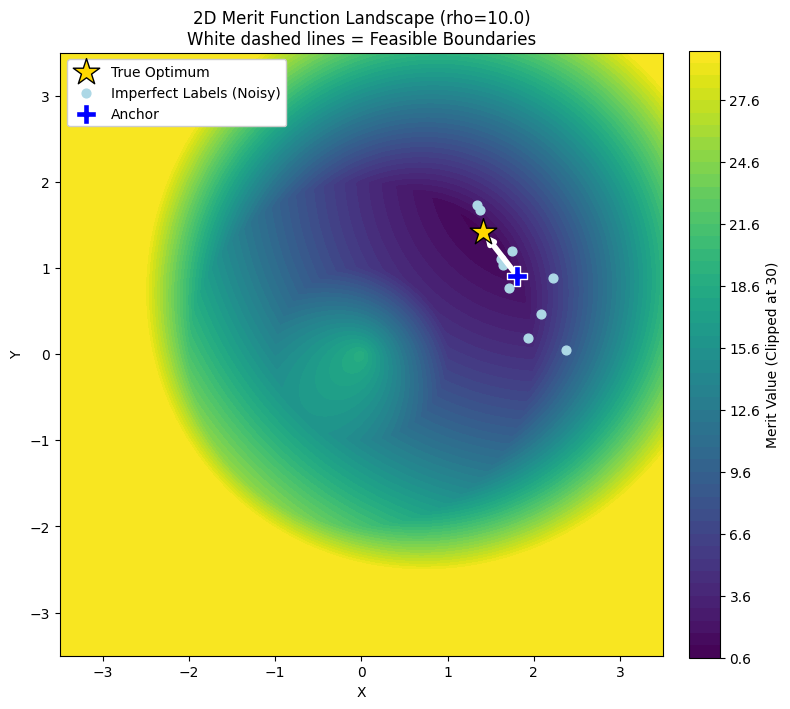

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Problem Constants
rho = 10.0      # Penalty Parameter (Controls steepness of walls)

# Constraint Violation: 0 inside donut (1<=r<=2), linear increase outside
violation = np.maximum(0, 1 - R) + np.maximum(0, R - 2)

# Merit Function: Objective + Penalty
Z_merit = Z_obj + rho * violation

# 3. Define Key Points (for visualization)
# True Optimum (Constrained at r=2)
opt_x = 2.0 * np.cos(target_angle)
opt_y = 2.0 * np.sin(target_angle)
opt_z = (opt_x - target_r * np.cos(target_angle))**2 + (opt_y - target_r * np.sin(target_angle))**2 

# Anchor (Supervised Init)
np.random.seed(42)
label_r = 2.0 + np.random.normal(0, 0.25, 10)
label_theta = target_angle + np.random.normal(0, 0.4, 10)
anchor_x = np.mean(label_r * np.cos(label_theta))
anchor_y = np.mean(label_r * np.sin(label_theta))

# Calculate Anchor Z-value on the Merit Surface
anchor_r = np.sqrt(anchor_x**2 + anchor_y**2)
anchor_viol = max(0, 1 - anchor_r) + max(0, anchor_r - 2)
anchor_obj = (anchor_x - target_r * np.cos(target_angle))**2 + (anchor_y - target_r * np.sin(target_angle))**2
anchor_z = anchor_obj + rho * anchor_viol

# 4. Plotting
fig, ax = plt.subplots(figsize=(8, 8))

# --- A. Filled Contours of Merit Function ---
# Use many levels to show the gradient
# Clip the upper values to keep the color scale useful for the "valley"
Z_plot = np.clip(Z_merit, 0, 30)
contour = ax.contourf(X, Y, Z_plot, levels=50, cmap='viridis', alpha=1.0)
cbar = fig.colorbar(contour, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Merit Value (Clipped at 30)')

# --- B. Add Specific Constraint Boundaries ---
# The feasible region is where violation is 0.
# We plot contour lines at r=1 and r=2.
boundary_inner = plt.Circle((0, 0), 1, color='white', fill=False, linestyle='--', linewidth=2, alpha=0.7)
boundary_outer = plt.Circle((0, 0), 2, color='white', fill=False, linestyle='--', linewidth=2, alpha=0.7)
# ax.add_patch(boundary_inner)
# ax.add_patch(boundary_outer)

# --- C. Add Points and Path ---
# True Optimum
ax.scatter(opt_x, opt_y, c='gold', s=400, marker='*', edgecolors='black', label='True Optimum', zorder=10)
ax.scatter(labels_x, labels_y, c='lightblue', s=40, alpha=1, label='Imperfect Labels (Noisy)')
# Anchor
ax.scatter(anchor_x, anchor_y, c='blue', s=200, marker='P', edgecolors='white', label='Anchor', zorder=10)
# "Slide" Path
ax.annotate("", xy=(opt_x, opt_y), xytext=(anchor_x, anchor_y),
            arrowprops=dict(arrowstyle="->", color='white', lw=4, label='Descent Path'))

# Formatting
ax.set_aspect('equal')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title(f"2D Merit Function Landscape (rho={rho})\nWhite dashed lines = Feasible Boundaries")
ax.legend(loc='upper left', framealpha=1)
ax.grid(False) # Grid can be distracting on contour plots

plt.tight_layout()

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Global Problem Configuration ---
class OptimizationProblem:
    def __init__(self):
        # Targets
        self.GLOBAL_MIN = np.array([2.0, 2.0])   # The "Star"
        self.TRAP_POS   = np.array([-1.5, -1.5]) # The "Decoy"

        # Trap Physics (Made stronger to ensure capture)
        self.TRAP_DEPTH = 11.0  # Deepened significantly
        self.TRAP_WIDTH = 3.0   # Widened to catch the gradient earlier

        # Constraint Boundaries
        self.R_INNER = 1.5
        self.R_OUTER = 3.5     # Expanded slightly to allow more movement
        
        self.rho = 6.0

    def eval_objective(self, x, y):
        # --- ASYMMETRY INTRODUCED HERE ---
        # Instead of a perfect circle (x^2 + y^2), we use an ellipse.
        # We also scale X and Y differently (0.2 vs 1.0) to create a "valley" shape.
        # This causes the path to curve: it descends the steep Y-slope fast, then crawls along X.
        
        dx = x - self.GLOBAL_MIN[0]
        dy = y - self.GLOBAL_MIN[1]
        
        # Elliptical Bowl: 0.2*dx^2 + 1.0*dy^2 (Steep in Y, Shallow in X)
        f_glob = 0.2 * dx**2 + 1.0 * dy**2
        df_glob_x = 0.2 * 2 * dx
        df_glob_y = 1.0 * 2 * dy
        
        # Gaussian Trap (Kept mostly the same)
        dist_sq = (x - self.TRAP_POS[0])**2 + (y - self.TRAP_POS[1])**2
        exp_term = self.TRAP_DEPTH * np.exp(-dist_sq / self.TRAP_WIDTH)
        f_trap = -exp_term
        
        df_trap_x = exp_term * (2/self.TRAP_WIDTH) * (x - self.TRAP_POS[0])
        df_trap_y = exp_term * (2/self.TRAP_WIDTH) * (y - self.TRAP_POS[1])
        
        return (f_glob + f_trap), (df_glob_x + df_trap_x), (df_glob_y + df_trap_y)

    def eval_constraint_violation(self, x, y):
        r = np.sqrt(x**2 + y**2)
        if r < 1e-6: r = 1e-6
        
        val, gx, gy = 0.0, 0.0, 0.0
        
        if r < self.R_INNER:
            val = self.R_INNER - r
            gx = -x/r
            gy = -y/r
        elif r > self.R_OUTER:
            val = r - self.R_OUTER
            gx = x/r
            gy = y/r
            
        return val, gx, gy

    def get_merit(self, x, y):
        obj, dox, doy = self.eval_objective(x, y)
        viol, dvx, dvy = self.eval_constraint_violation(x, y)
        return obj + self.rho * viol, dox + self.rho * dvx, doy + self.rho * dvy

    def run_descent(self, start_x, start_y, lr=0.02, max_steps=200, tol=1e-4):
        path_x, path_y = [start_x], [start_y]
        curr_x, curr_y = start_x, start_y
        
        for _ in range(max_steps):
            _, gx, gy = self.get_merit(curr_x, curr_y)
            
            # Check Gradient Norm (Stopping Condition)
            grad_norm = np.sqrt(gx**2 + gy**2)
            if grad_norm < tol:
                break
            
            curr_x -= lr * gx
            curr_y -= lr * gy
            path_x.append(curr_x)
            path_y.append(curr_y)
            
        return np.array(path_x), np.array(path_y)
# Initialize
prob = OptimizationProblem()

# Compute Landscape
feature_x = np.linspace(-4, 4, 300)
feature_y = np.linspace(-4, 4, 300)
X, Y = np.meshgrid(feature_x, feature_y)
Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i,j], _, _ = prob.get_merit(X[i,j], Y[i,j])

Good Anchor Final Position: (1.534, 1.987, objective=0.035)
Random Init Final Position: (-1.411, -0.643, objective=0.724)


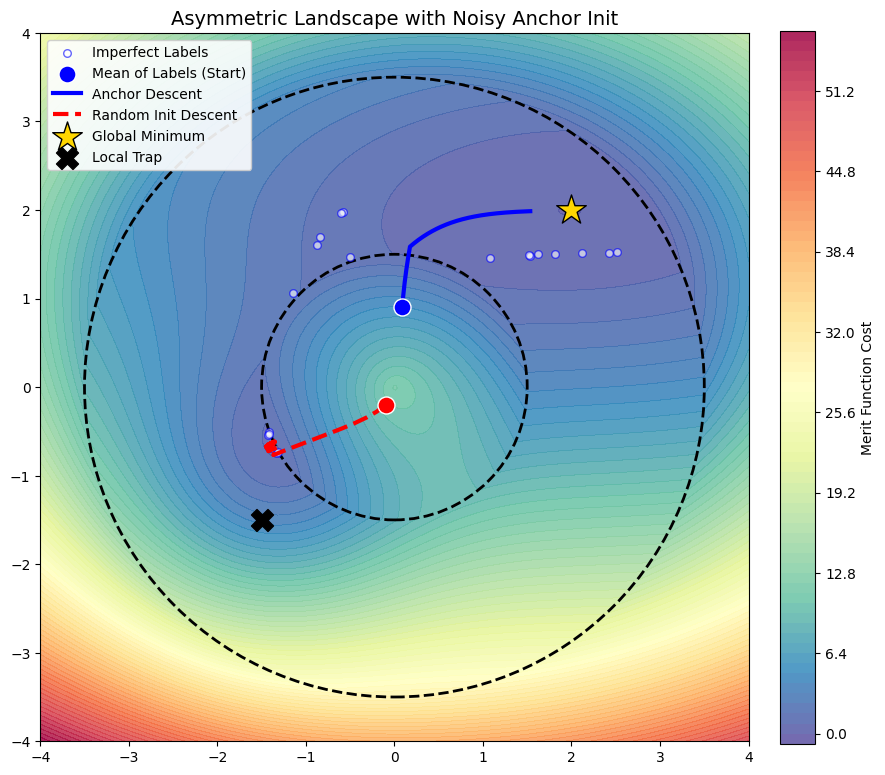

In [142]:
# --- 2. Run Scenarios ---

# Scenario A: "Good Anchor" via Imperfect Labels

np.random.seed(42)
n_samples = 20

# A. Start with totally random points in the space [-4, 4]
raw_init_x = np.random.uniform(-3, 3, n_samples)
raw_init_y = np.random.uniform(-3, 3, n_samples)

imperfect_labels_x = []
imperfect_labels_y = []

# B. Run "Loose" Solver (High Tolerance = Stop Early)
LOOSE_TOL = 1.0  # <--- Stops as soon as gradient is "okayish"

for i in range(n_samples):
    # Run descent but stop when gradients are still relatively high
    px, py = prob.run_descent(raw_init_x[i], raw_init_y[i], tol=LOOSE_TOL)
    
    # Take the final point of this "cheap" run as the label
    imperfect_labels_x.append(px[-1])
    imperfect_labels_y.append(py[-1])

imperfect_labels_x = np.array(imperfect_labels_x)
imperfect_labels_y = np.array(imperfect_labels_y)

# 2. Compute Mean
anchor_start_x = np.mean(imperfect_labels_x)
anchor_start_y = np.mean(imperfect_labels_y)

# 3. Run Descent from Mean
anchor_path_x, anchor_path_y = prob.run_descent(anchor_start_x, anchor_start_y)

# Scenario B: Random/Bad Init (Trapped)
random_path_x, random_path_y = prob.run_descent(-0.1, -0.2)

# print solutions
print(f"Good Anchor Final Position: ({anchor_path_x[-1]:.3f}, {anchor_path_y[-1]:.3f}, objective={prob.get_merit(anchor_path_x[-1], anchor_path_y[-1])[0]:.3f})")
print(f"Random Init Final Position: ({random_path_x[-1]:.3f}, {random_path_y[-1]:.3f}, objective={prob.get_merit(random_path_x[-1], random_path_y[-1])[0]:.3f})")

# --- 3. Plotting ---
fig, ax = plt.subplots(figsize=(10, 10))

# Landscape
cp = ax.contourf(X, Y, Z, levels=70, cmap='Spectral_r', alpha=0.85)
cbar = fig.colorbar(cp, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Merit Function Cost')

# Boundaries
boundary_inner = plt.Circle((0, 0), prob.R_INNER, color='black', fill=False, linestyle='--', linewidth=2)
boundary_outer = plt.Circle((0, 0), prob.R_OUTER, color='black', fill=False, linestyle='--', linewidth=2)
ax.add_patch(boundary_inner)
ax.add_patch(boundary_outer)

# --- Plot Anchor (Imperfect Labels + Mean + Path) ---
# 1. The Noisy Labels
ax.scatter(imperfect_labels_x, imperfect_labels_y, c='white', s=30, alpha=0.6, edgecolors='blue', label='Imperfect Labels')
# 2. The Mean (Start)
ax.scatter([anchor_start_x], [anchor_start_y], c='blue', s=150, edgecolors='white', zorder=10, label='Mean of Labels (Start)')
# 3. The Path
ax.plot(anchor_path_x, anchor_path_y, color='blue', linewidth=3, label='Anchor Descent')

# --- Plot Random Init ---
ax.plot(random_path_x, random_path_y, color='red', linewidth=3, linestyle='--', label='Random Init Descent')
ax.scatter([random_path_x[0]], [random_path_y[0]], c='red', s=150, edgecolors='white', zorder=10)

# Targets
ax.scatter([prob.GLOBAL_MIN[0]], [prob.GLOBAL_MIN[1]], c='gold', marker='*', s=500, edgecolors='black', label='Global Minimum', zorder=15)
ax.scatter([prob.TRAP_POS[0]], [prob.TRAP_POS[1]], c='black', marker='X', s=250, label='Local Trap', zorder=15)

# Formatting
ax.set_aspect('equal')
ax.set_title("Asymmetric Landscape with Noisy Anchor Init", fontsize=14)
ax.legend(loc='upper left', framealpha=0.9)

plt.show()

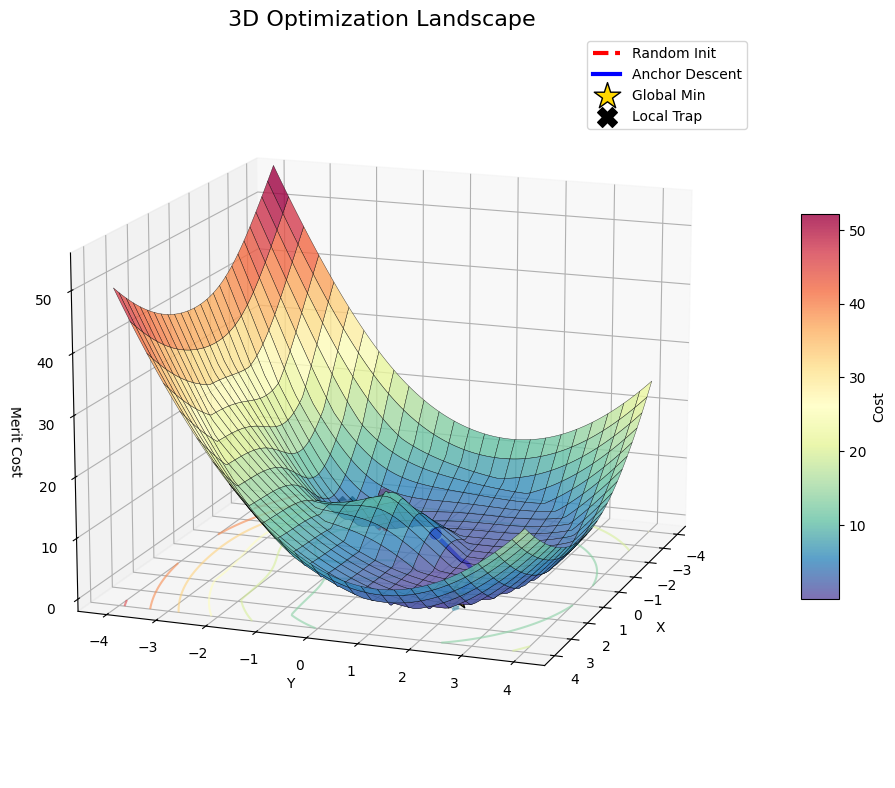

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting

# --- 1. Global Problem Configuration (Unchanged) ---
class OptimizationProblem:
    def __init__(self):
        # Targets
        self.GLOBAL_MIN = np.array([2.0, 2.0])   # The "Star"
        self.TRAP_POS   = np.array([-1.5, -1.5]) # The "Decoy"

        # Trap Physics
        self.TRAP_DEPTH = 11.0
        self.TRAP_WIDTH = 3.0

        # Constraint Boundaries
        self.R_INNER = 1.5
        self.R_OUTER = 3.5
        
        self.rho = 6.0

    def eval_objective(self, x, y):
        dx = x - self.GLOBAL_MIN[0]
        dy = y - self.GLOBAL_MIN[1]
        
        # Elliptical Bowl
        f_glob = 0.2 * dx**2 + 1.0 * dy**2
        df_glob_x = 0.2 * 2 * dx
        df_glob_y = 1.0 * 2 * dy
        
        # Gaussian Trap
        dist_sq = (x - self.TRAP_POS[0])**2 + (y - self.TRAP_POS[1])**2
        exp_term = self.TRAP_DEPTH * np.exp(-dist_sq / self.TRAP_WIDTH)
        f_trap = -exp_term
        
        df_trap_x = exp_term * (2/self.TRAP_WIDTH) * (x - self.TRAP_POS[0])
        df_trap_y = exp_term * (2/self.TRAP_WIDTH) * (y - self.TRAP_POS[1])
        
        return (f_glob + f_trap), (df_glob_x + df_trap_x), (df_glob_y + df_trap_y)

    def eval_constraint_violation(self, x, y):
        r = np.sqrt(x**2 + y**2)
        if r < 1e-6: r = 1e-6
        val, gx, gy = 0.0, 0.0, 0.0
        
        if r < self.R_INNER:
            val = self.R_INNER - r
            gx = -x/r; gy = -y/r
        elif r > self.R_OUTER:
            val = r - self.R_OUTER
            gx = x/r; gy = y/r
        return val, gx, gy

    def get_merit(self, x, y):
        obj, dox, doy = self.eval_objective(x, y)
        viol, dvx, dvy = self.eval_constraint_violation(x, y)
        return obj + self.rho * viol, dox + self.rho * dvx, doy + self.rho * dvy

    def run_descent(self, start_x, start_y, lr=0.02, max_steps=200, tol=1e-4):
        path_x, path_y = [start_x], [start_y]
        curr_x, curr_y = start_x, start_y
        for _ in range(max_steps):
            _, gx, gy = self.get_merit(curr_x, curr_y)
            grad_norm = np.sqrt(gx**2 + gy**2)
            if grad_norm < tol: break
            curr_x -= lr * gx
            curr_y -= lr * gy
            path_x.append(curr_x)
            path_y.append(curr_y)
        return np.array(path_x), np.array(path_y)

# Initialize
prob = OptimizationProblem()

# --- 2. Compute Landscape (Reduced resolution for cleaner 3D mesh) ---
# Note: 3D plots look better with slightly fewer points than 2D contours
feature_x = np.linspace(-4, 4, 100) 
feature_y = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(feature_x, feature_y)
Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i,j], _, _ = prob.get_merit(X[i,j], Y[i,j])

# --- 3. Run Scenarios (Same as before) ---
np.random.seed(42)
n_samples = 20
raw_init_x = np.random.uniform(-3, 3, n_samples)
raw_init_y = np.random.uniform(-3, 3, n_samples)
imperfect_labels_x = []
imperfect_labels_y = []
LOOSE_TOL = 1.0

for i in range(n_samples):
    px, py = prob.run_descent(raw_init_x[i], raw_init_y[i], tol=LOOSE_TOL)
    imperfect_labels_x.append(px[-1])
    imperfect_labels_y.append(py[-1])

anchor_start_x = np.mean(imperfect_labels_x)
anchor_start_y = np.mean(imperfect_labels_y)
anchor_path_x, anchor_path_y = prob.run_descent(anchor_start_x, anchor_start_y)
random_path_x, random_path_y = prob.run_descent(-0.1, -0.2)

# --- 4. Helper to get Z-values for paths ---
def get_z_path(path_x, path_y):
    z_vals = []
    for x, y in zip(path_x, path_y):
        val, _, _ = prob.get_merit(x, y)
        z_vals.append(val)
    return np.array(z_vals)

anchor_path_z = get_z_path(anchor_path_x, anchor_path_y)
random_path_z = get_z_path(random_path_x, random_path_y)

# --- 5. 3D Plotting ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# A. Plot the Surface
# rstride/cstride controls how sparse the grid lines are
surf = ax.plot_surface(X, Y, Z, cmap='Spectral_r', alpha=0.8, 
                       edgecolor='k', linewidth=0.3, rstride=4, cstride=4)

# B. Add Contour Projection on the Bottom (Floor)
min_z = np.min(Z) - 2.0 # Offset slightly below the lowest point
ax.contour(X, Y, Z, zdir='z', offset=min_z, cmap='Spectral_r', alpha=0.6)

# C. Plot Paths in 3D
# 1. Random Init (Red)
ax.plot(random_path_x, random_path_y, random_path_z, color='red', linewidth=3, linestyle='--', label='Random Init')
ax.scatter([random_path_x[0]], [random_path_y[0]], [random_path_z[0]], color='red', s=100, edgecolor='white')

# 2. Anchor Init (Blue)
ax.plot(anchor_path_x, anchor_path_y, anchor_path_z, color='blue', linewidth=3, label='Anchor Descent')
ax.scatter([anchor_start_x], [anchor_start_y], [anchor_path_z[0]], color='blue', s=100, edgecolor='white')

# D. Targets
# Global Min
gm_z, _, _ = prob.get_merit(prob.GLOBAL_MIN[0], prob.GLOBAL_MIN[1])
ax.scatter([prob.GLOBAL_MIN[0]], [prob.GLOBAL_MIN[1]], [gm_z], c='gold', marker='*', s=400, edgecolors='black', label='Global Min', zorder=20)

# Trap
trap_z, _, _ = prob.get_merit(prob.TRAP_POS[0], prob.TRAP_POS[1])
ax.scatter([prob.TRAP_POS[0]], [prob.TRAP_POS[1]], [trap_z], c='black', marker='X', s=200, label='Local Trap', zorder=20)

# E. Formatting
ax.set_title("3D Optimization Landscape", fontsize=16)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Merit Cost')
ax.set_zlim(min_z, np.max(Z)) # Ensure floor contours are visible
ax.view_init(elev=15, azim=20) # Adjust camera angle for best view

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Cost')
plt.legend(loc='upper right')
plt.show()